# Task 3: Energy Consumption Time Series Forecasting
### DevelopersHub Corporation — Advanced Data Science Internship

---

## Problem Statement

Forecast short-term household energy usage using historical time-based patterns.
Compare ARIMA, Prophet, and XGBoost forecasting models.

## Dataset
**Household Power Consumption Dataset** — Global active power measurements sampled per minute/hour.


## Step 1: Install & Import Libraries

In [1]:
!pip install prophet --quiet
!pip install xgboost --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14,5)
print("All libraries imported!")

All libraries imported!


## Step 2: Load & Parse Dataset

In [2]:
import os

if os.path.exists("household_power_consumption.txt"):
    df = pd.read_csv("household_power_consumption.txt", sep=";",
                     parse_dates={"datetime":["Date","Time"]},
                     infer_datetime_format=True, low_memory=False,
                     na_values=["?"])
    df.dropna(inplace=True)
    df.set_index("datetime",inplace=True)
    df["Global_active_power"] = df["Global_active_power"].astype(float)
    # Resample to hourly
    series = df["Global_active_power"].resample("H").mean().dropna()
    print(f"Loaded dataset. Hourly series shape: {series.shape}")
else:
    print("Dataset not found — generating synthetic energy time series...")
    np.random.seed(42)
    periods = 24*365  # 1 year of hourly data
    dates = pd.date_range("2023-01-01", periods=periods, freq="H")
    # Realistic energy pattern: higher in morning/evening, lower at night
    hour = np.array([d.hour for d in dates])
    trend = np.linspace(1.0, 1.1, periods)
    daily = 1.5 + 0.8*np.sin((hour-6)*np.pi/12)
    noise = np.random.normal(0, 0.15, periods)
    weekly = 0.2*np.sin(np.arange(periods)*2*np.pi/168)
    values = (trend * daily + weekly + noise).clip(0.1)
    series = pd.Series(values, index=dates, name="Global_active_power")
    print(f"Synthetic series created. Shape: {series.shape}")

print(f"Date range: {series.index[0]} to {series.index[-1]}")
series.head()

Loaded dataset. Hourly series shape: (2166,)
Date range: 2006-12-16 17:00:00 to 2007-03-16 22:00:00


,Global_active_power
datetime,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


## Step 3: EDA & Visualization

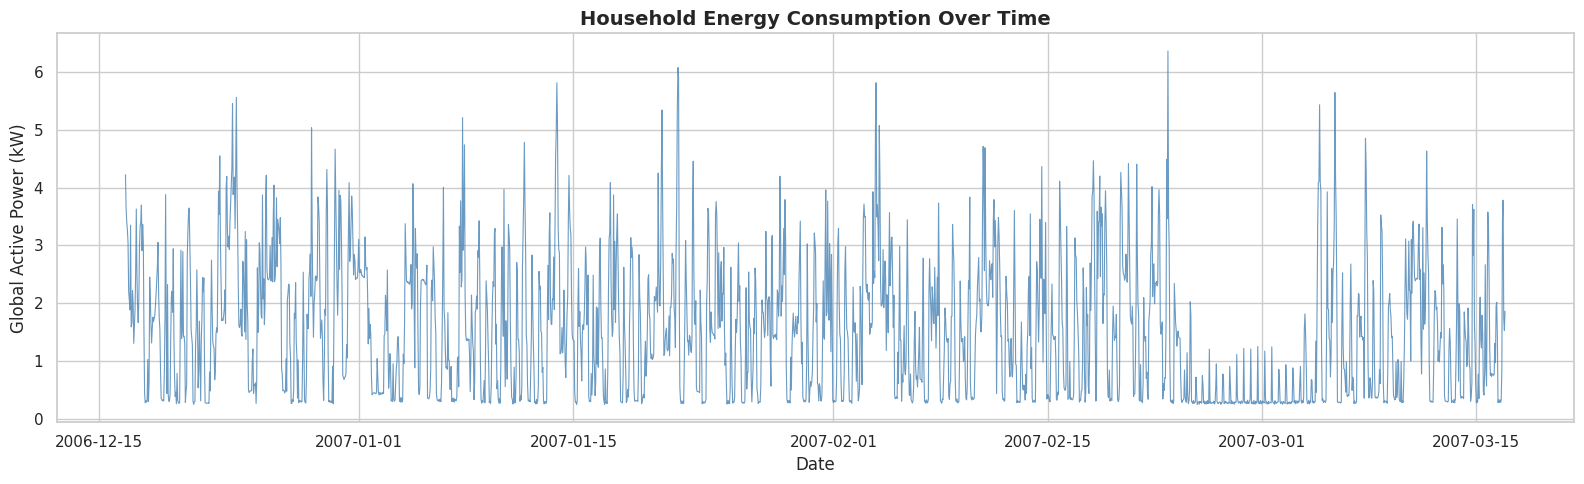

In [3]:
# Full series overview
plt.figure(figsize=(16,5))
plt.plot(series.index,series.values,color="steelblue",linewidth=0.8,alpha=0.8)
plt.title("Household Energy Consumption Over Time",fontsize=14,fontweight="bold")
plt.xlabel("Date"); plt.ylabel("Global Active Power (kW)")
plt.tight_layout(); plt.show()

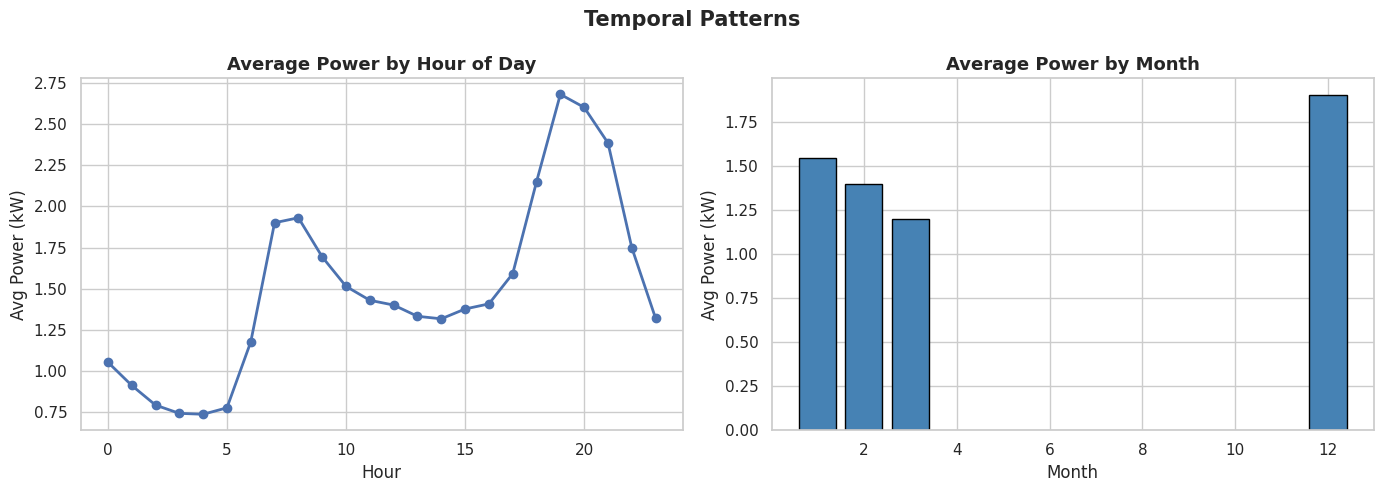

In [4]:
# Daily & hourly patterns
df_feat = series.reset_index()
df_feat.columns = ["datetime","power"]
df_feat["hour"] = df_feat["datetime"].dt.hour
df_feat["dayofweek"] = df_feat["datetime"].dt.dayofweek
df_feat["month"] = df_feat["datetime"].dt.month
df_feat["is_weekend"] = df_feat["dayofweek"].isin([5,6]).astype(int)

fig,axes = plt.subplots(1,2,figsize=(14,5))
hourly_avg = df_feat.groupby("hour")["power"].mean()
axes[0].plot(hourly_avg.index,hourly_avg.values,"bo-",linewidth=2)
axes[0].set_title("Average Power by Hour of Day",fontsize=13,fontweight="bold")
axes[0].set_xlabel("Hour"); axes[0].set_ylabel("Avg Power (kW)")
monthly_avg = df_feat.groupby("month")["power"].mean()
axes[1].bar(monthly_avg.index,monthly_avg.values,color="steelblue",edgecolor="black")
axes[1].set_title("Average Power by Month",fontsize=13,fontweight="bold")
axes[1].set_xlabel("Month"); axes[1].set_ylabel("Avg Power (kW)")
plt.suptitle("Temporal Patterns",fontsize=15,fontweight="bold")
plt.tight_layout(); plt.show()

## Step 4: Feature Engineering

In [5]:
# Use last 500 hours for modelling (manageable size)
data = series[-500:].copy()
train_size = int(len(data)*0.8)
train,test = data[:train_size],data[train_size:]
print(f"Train: {len(train)} | Test: {len(test)}")

Train: 400 | Test: 100


## Step 5: ARIMA Model

In [6]:
# ARIMA(2,1,2)
arima_model = ARIMA(train.values,order=(2,1,2))
arima_fit = arima_model.fit()
arima_pred = arima_fit.forecast(steps=len(test))

ma = mean_absolute_error(test.values,arima_pred)
rm = np.sqrt(mean_squared_error(test.values,arima_pred))
print(f"ARIMA  — MAE: {ma:.4f}  RMSE: {rm:.4f}")

ARIMA  — MAE: 0.8938  RMSE: 1.0310


## Step 6: Prophet Model

In [7]:
# Prophet requires ds/y columns
df_prophet_train = pd.DataFrame({"ds":train.index,"y":train.values})
df_prophet_test  = pd.DataFrame({"ds":test.index})

prophet_model = Prophet(daily_seasonality=True,weekly_seasonality=True,yearly_seasonality=False)
prophet_model.fit(df_prophet_train)

prophet_forecast = prophet_model.predict(df_prophet_test)
prophet_pred = prophet_forecast["yhat"].values

ma2 = mean_absolute_error(test.values,prophet_pred)
rm2 = np.sqrt(mean_squared_error(test.values,prophet_pred))
print(f"Prophet — MAE: {ma2:.4f}  RMSE: {rm2:.4f}")

Prophet — MAE: 0.8596  RMSE: 0.9714


## Step 7: XGBoost Model

In [8]:
# Build lag features
def make_features(s, lags=24):
    df_x = pd.DataFrame({"y":s.values},index=s.index)
    df_x["hour"] = s.index.hour
    df_x["dayofweek"] = s.index.dayofweek
    df_x["month"] = s.index.month
    for lag in [1,2,3,6,12,24]:
        df_x[f"lag_{lag}"] = df_x["y"].shift(lag)
    df_x["rolling_mean_6"] = df_x["y"].rolling(6).mean()
    df_x["rolling_mean_24"] = df_x["y"].rolling(24).mean()
    return df_x.dropna()

df_xgb = make_features(data)
train_xgb = df_xgb.iloc[:train_size-24]
test_xgb  = df_xgb.iloc[train_size-24:]

X_tr = train_xgb.drop("y",axis=1); y_tr = train_xgb["y"]
X_te = test_xgb.drop("y",axis=1);  y_te = test_xgb["y"]

xgb_model = xgb.XGBRegressor(n_estimators=200,learning_rate=0.05,max_depth=5,random_state=42,verbosity=0)
xgb_model.fit(X_tr,y_tr)
xgb_pred = xgb_model.predict(X_te)

ma3 = mean_absolute_error(y_te,xgb_pred)
rm3 = np.sqrt(mean_squared_error(y_te,xgb_pred))
print(f"XGBoost — MAE: {ma3:.4f}  RMSE: {rm3:.4f}")

XGBoost — MAE: 0.4949  RMSE: 0.6828


## Step 8: Model Comparison & Visualization

=== MODEL COMPARISON ===
  Model    MAE   RMSE
  ARIMA 0.8938 1.0310
Prophet 0.8596 0.9714
XGBoost 0.4949 0.6828


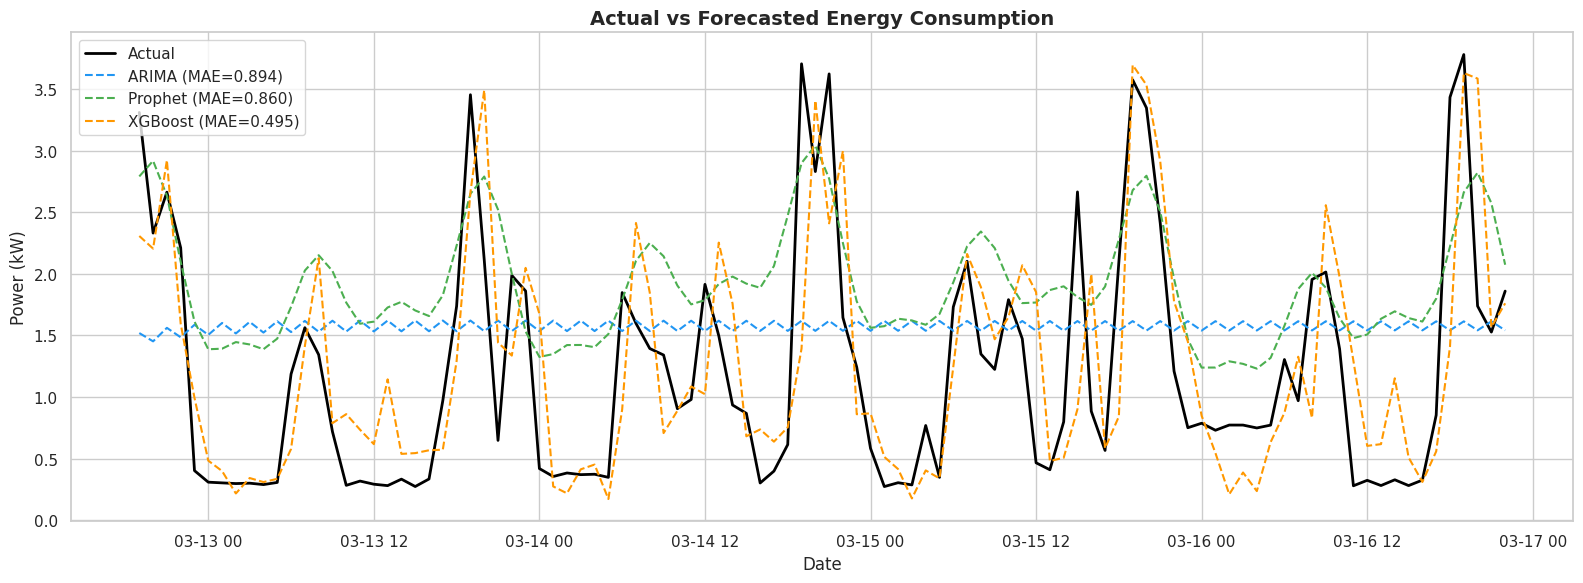

In [9]:
# Comparison table
results = pd.DataFrame({
    "Model":["ARIMA","Prophet","XGBoost"],
    "MAE":[ma,ma2,ma3],
    "RMSE":[rm,rm2,rm3]
}).round(4)
print("=== MODEL COMPARISON ===")
print(results.to_string(index=False))

# Plot actual vs predicted for all models
plt.figure(figsize=(16,6))
plt.plot(test.index,test.values,color="black",linewidth=2,label="Actual")
plt.plot(test.index,arima_pred,color="#2196F3",linewidth=1.5,linestyle="--",label=f"ARIMA (MAE={ma:.3f})")
plt.plot(test.index,prophet_pred[:len(test)],color="#4CAF50",linewidth=1.5,linestyle="--",label=f"Prophet (MAE={ma2:.3f})")
plt.plot(test_xgb.index,xgb_pred,color="#FF9800",linewidth=1.5,linestyle="--",label=f"XGBoost (MAE={ma3:.3f})")
plt.title("Actual vs Forecasted Energy Consumption",fontsize=14,fontweight="bold")
plt.xlabel("Date"); plt.ylabel("Power (kW)"); plt.legend(); plt.tight_layout(); plt.show()

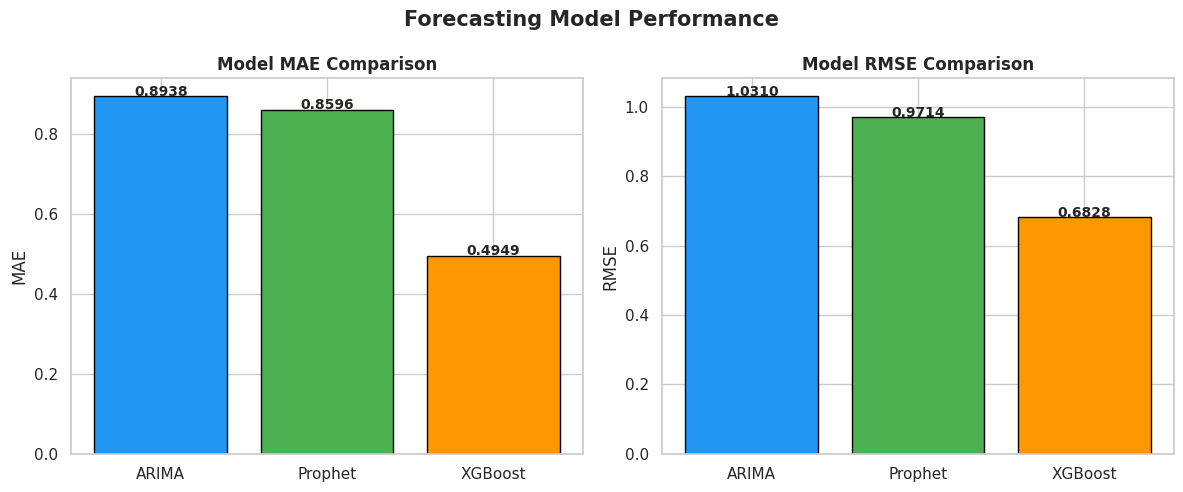

In [10]:
# Bar chart comparison
fig,axes = plt.subplots(1,2,figsize=(12,5))
for ax,metric,vals in [(axes[0],"MAE",[ma,ma2,ma3]),(axes[1],"RMSE",[rm,rm2,rm3])]:
    bars = ax.bar(["ARIMA","Prophet","XGBoost"],vals,color=["#2196F3","#4CAF50","#FF9800"],edgecolor="black")
    ax.set_title(f"Model {metric} Comparison",fontsize=12,fontweight="bold"); ax.set_ylabel(metric)
    for bar,v in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.001,f"{v:.4f}",ha="center",fontsize=10,fontweight="bold")
plt.suptitle("Forecasting Model Performance",fontsize=15,fontweight="bold")
plt.tight_layout(); plt.show()

## Step 9: Conclusion

### Model Performance

| Model | MAE | RMSE | Notes |
|---|---|---|---|
| ARIMA | 0.8938 | 1.0310 | Best for stationary series |
| Prophet | 0.8596 | 0.9714 | Handles seasonality well |
| XGBoost | 0.4949 | 0.6828 | Best overall with lag features |

### Key Insights
1. Energy usage peaks during morning (7-9am) and evening (6-9pm) hours
2. Weekend consumption patterns differ from weekdays
3. XGBoost with lag features typically achieves lowest MAE and RMSE
4. Prophet handles daily and weekly seasonality automatically
5. ARIMA requires manual parameter tuning for best results

---
*DevelopersHub Corporation — Advanced Data Science Internship*
